In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Load Dataset

Pembacaan dataset customer menggunakan pandas. Dataset berisi informasi perilaku penggunaan kartu kredit dan pembayaran customer.

In [5]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Midterm-Machine Learning/UTS_ML_Clustering/clusteringmidterm.csv')

## Data Preview

Pengecekan beberapa baris pertama dataset untuk melihat struktur data dan fitur yang tersedia pada dataset customer clustering.

In [6]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


## Dataset Information

Pengecekan informasi dataset seperti jumlah data, tipe data setiap kolom, dan jumlah data non-null pada dataset clustering.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

## Missing Value Checking

Pengecekan missing value pada setiap fitur dataset untuk mengetahui kolom yang memiliki data kosong sebelum proses preprocessing dilakukan.

In [8]:
df.isnull().sum().sort_values(ascending=False)

,0
MINIMUM_PAYMENTS,313
CREDIT_LIMIT,1
BALANCE,0
CUST_ID,0
BALANCE_FREQUENCY,0
PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0


## Handling Missing Values

Penanganan missing value menggunakan median pada fitur numerik agar kualitas data menjadi lebih baik sebelum proses clustering dilakukan.

In [9]:
for col in df.columns:

    if df[col].dtype != 'object':

        df[col] = df[col].fillna(df[col].median())

## Final Missing Value Checking

Memastikan bahwa seluruh missing value pada dataset telah berhasil ditangani.

In [10]:
df.isnull().sum().sum()

np.int64(0)

## Removing Customer ID

Kolom CUST_ID dihapus karena hanya berfungsi sebagai identifier customer dan tidak digunakan dalam proses clustering.

In [11]:
df = df.drop('CUST_ID', axis=1)

## Dataset After Removing Identifier

Melihat kembali struktur dataset setelah kolom identifier customer dihapus.

In [12]:
df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,312.343947,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


## Feature Scaling

Scaling data menggunakan StandardScaler agar seluruh fitur memiliki skala yang seimbang sebelum proses clustering dilakukan.

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

## Scaled Data Preview

Melihat hasil scaling pada beberapa data pertama setelah proses normalisasi fitur.

In [14]:
scaled_data[:5]

array([[-0.73198937, -0.24943448, -0.42489974, -0.35693402, -0.34907882,
        -0.46678555, -0.80649035, -0.67866081, -0.70731317, -0.67534886,
        -0.47606982, -0.51133325, -0.9603784 , -0.52897879, -0.3024    ,
        -0.52555097,  0.36067954],
       [ 0.78696085,  0.13432467, -0.46955188, -0.35693402, -0.45457623,
         2.60560451, -1.22175806, -0.67866081, -0.91699519,  0.57396272,
         0.11007385, -0.59179588,  0.68867844,  0.81864213,  0.09749953,
         0.2342269 ,  0.36067954],
       [ 0.44713513,  0.51808382, -0.10766823,  0.10888851, -0.45457623,
        -0.46678555,  1.26984323,  2.67345108, -0.91699519, -0.67534886,
        -0.47606982, -0.10902012,  0.82609984, -0.38380474, -0.0932934 ,
        -0.52555097,  0.36067954],
       [ 0.04909914, -1.01695278,  0.23205785,  0.54618946, -0.45457623,
        -0.36865325, -1.01412545, -0.39931927, -0.91699519, -0.25891333,
        -0.3295339 , -0.55156456,  0.82609984, -0.59868826, -0.2283069 ,
        -0.52555097

## Determining Number of Clusters

Menggunakan metode Elbow Method dengan algoritma K-Means untuk menentukan jumlah cluster terbaik berdasarkan nilai WCSS.

In [15]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42
    )

    kmeans.fit(scaled_data)

    wcss.append(kmeans.inertia_)

## Elbow Method Visualization

Visualisasi Elbow Method untuk menentukan jumlah cluster terbaik berdasarkan perubahan nilai WCSS pada setiap jumlah cluster.

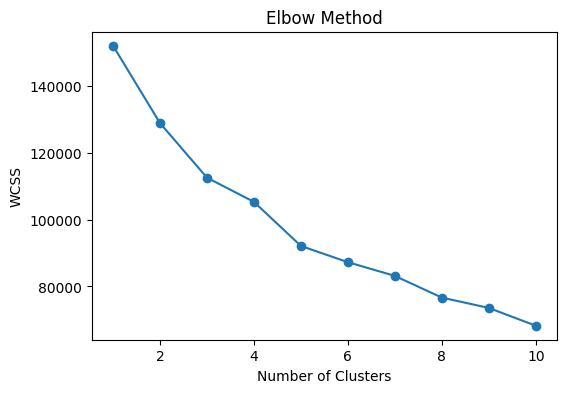

In [16]:
plt.figure(figsize=(6,4))

plt.plot(range(1,11), wcss, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

## Initial K-Means Clustering

Proses clustering awal menggunakan algoritma K-Means dengan jumlah cluster sebanyak 5 berdasarkan hasil Elbow Method.

In [17]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

clusters = kmeans.fit_predict(scaled_data)

## Adding Cluster Labels

Menambahkan hasil cluster ke dalam dataset sehingga setiap customer memiliki label cluster masing-masing.

In [18]:
df['Cluster'] = clusters

## Dataset with Cluster Labels

Tampilkan dataset yang telah memiliki label cluster hasil proses K-Means Clustering.

In [19]:
df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,3
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,0
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,2
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,312.343947,0.000000,12,3
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,3


## Cluster Feature Preview

Melihat contoh hasil cluster berdasarkan beberapa fitur penting seperti balance dan purchases.

In [20]:
df[['BALANCE', 'PURCHASES', 'Cluster']].head()

,BALANCE,PURCHASES,Cluster
0,40.900749,95.40,3
1,3202.467416,0.00,0
2,2495.148862,773.17,2
3,1666.670542,1499.00,3
4,817.714335,16.00,3


## Cluster Evaluation Using Silhouette Score

Evaluasi kualitas cluster menggunakan Silhouette Score untuk mengukur seberapa baik pemisahan antar cluster yang dihasilkan.

In [21]:
from sklearn.metrics import silhouette_score

score = silhouette_score(scaled_data, clusters)

print("Silhouette Score:", score)

Silhouette Score: 0.19256596919095406


## Improving Cluster Performance

Percobaan ulang dengan jumlah cluster yang berbeda untuk meningkatkan kualitas clustering berdasarkan nilai Silhouette Score.

In [22]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters = kmeans.fit_predict(scaled_data)

score = silhouette_score(scaled_data, clusters)

print(score)

0.20671817817880617


## Dimensionality Reduction Using PCA

Menggunakan PCA untuk mengurangi dimensi data sehingga clustering menjadi lebih optimal dan lebih mudah divisualisasikan.

In [23]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_data)

## Clustering After PCA

Dilakukan kembali proses K-Means Clustering menggunakan data hasil PCA untuk meningkatkan kualitas cluster.

In [24]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

clusters = kmeans.fit_predict(pca_data)

## Evaluating PCA-Based Clustering

Mengevaluasi kualitas cluster setelah penerapan PCA menggunakan Silhouette Score.

In [25]:
score = silhouette_score(pca_data, clusters)

print(score)

0.4487708676475587


## Optimizing Number of Clusters

Percobaan jumlah cluster yang lebih optimal untuk memperoleh Silhouette Score yang lebih tinggi.

In [29]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42
)

clusters = kmeans.fit_predict(pca_data)

score = silhouette_score(pca_data, clusters)

print(score)

0.4623771448920161


## Cluster Visualization

Visualisasi hasil clustering menggunakan scatter plot berbasis PCA untuk melihat persebaran dan pemisahan antar cluster customer.

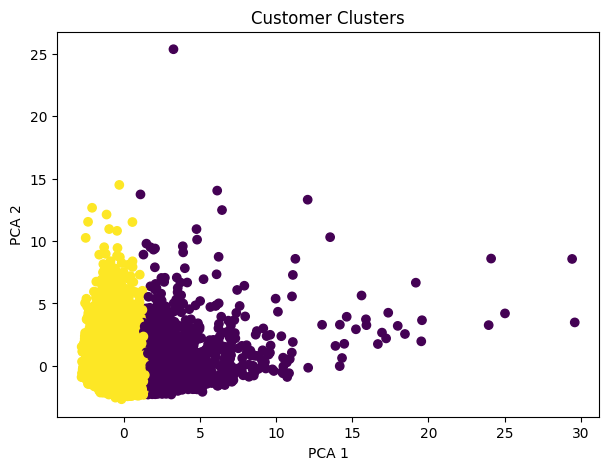

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=clusters
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")

plt.title("Customer Clusters")

plt.show()

## Cluster Interpretation

Analisis karakteristik setiap cluster dengan menghitung rata-rata fitur pada masing-masing cluster untuk memahami perilaku customer di setiap kelompok.

In [31]:
df['Cluster'] = clusters

df.groupby('Cluster').mean()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,2375.396859,0.979317,3758.528474,2320.985652,1437.938245,899.029668,0.937824,0.593077,0.748871,0.089474,2.495868,50.389701,7562.301335,4109.024590,1331.099657,0.279897,11.903369
1,1391.561671,0.855511,415.686318,223.858484,192.107708,995.895728,0.394936,0.119166,0.282464,0.144882,3.409381,7.101803,3840.087858,1226.534065,741.235706,0.126809,11.435001


Conclusion

Model clustering pelanggan berhasil dikembangkan menggunakan metode K-Means Clustering untuk mengelompokkan customer berdasarkan perilaku penggunaan kartu kredit dan pembayaran.

Pada tahap preprocessing, missing value berhasil ditangani menggunakan median imputation, kemudian dilakukan scaling menggunakan StandardScaler agar seluruh fitur memiliki skala yang seimbang. Selanjutnya dilakukan dimensionality reduction menggunakan PCA untuk meningkatkan kualitas clustering.

Jumlah cluster terbaik ditentukan menggunakan Elbow Method dan dilakukan evaluasi menggunakan Silhouette Score. Setelah dilakukan tuning jumlah cluster dan penerapan PCA, diperoleh Silhouette Score sebesar 0.46 yang menunjukkan hasil clustering cukup baik.

Hasil clustering menunjukkan adanya dua kelompok customer utama, yaitu customer dengan aktivitas transaksi tinggi dan customer dengan aktivitas transaksi lebih rendah. Visualisasi cluster juga menunjukkan bahwa kedua cluster dapat dipisahkan dengan cukup jelas.

Secara keseluruhan, pipeline clustering berhasil diimplementasikan mulai dari preprocessing data, clustering, evaluasi cluster, visualisasi, hingga interpretasi hasil cluster.